# Laboratorio 2: Segmentación simple por color

## Una aplicación integrada de los conceptos de la unidad

En este laboratorio vas a ver cómo se conectan varias ideas que ya trabajaste: representación del color, canales, histogramas, umbrales y cuantización. La meta no es solo obtener una máscara, sino entender por qué una estrategia de segmentación funciona mejor que otra.

## Objetivos

- Analizar una imagen color con criterios simples.
- Separar canales y leer histogramas.
- Definir umbrales para una segmentación por color.
- Delimitar la región segmentada con una caja y una etiqueta.
- Comparar resultados con distintos parámetros.
- Relacionar segmentación y cuantización.


## Recordatorio

En este laboratorio vamos a trabajar con una imagen de flores. El color elegido como ejemplo principal es el rojo, pero lo importante no es memorizar un valor exacto de umbral. Lo importante es ver cómo la elección de parámetros se apoya en una lectura previa de la imagen.


In [1]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


def mostrar_rgb(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_histogramas(r, g, b):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, canal, color, titulo in zip(
        axes,
        [r, g, b],
        ["red", "green", "blue"],
        ["Canal rojo", "Canal verde", "Canal azul"],
    ):
        hist, bins = np.histogram(canal.flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(titulo)
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, g_max, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (rojo >= r_min) & (verde <= g_max) & (azul <= b_max)
    return mascara


def dibujar_caja_delimitadora(imagen_rgb, mascara, etiqueta):
    mascara_uint8 = (mascara.astype(np.uint8)) * 255
    contornos, _ = cv2.findContours(mascara_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contornos:
        print("No se encontraron regiones segmentadas para dibujar una caja.")
        return

    contorno_principal = max(contornos, key=cv2.contourArea)
    x, y, ancho, alto = cv2.boundingRect(contorno_principal)
    area = cv2.contourArea(contorno_principal)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(imagen_rgb)

    rectangulo = Rectangle(
        (x, y),
        ancho,
        alto,
        fill=False,
        edgecolor="yellow",
        linewidth=3,
    )
    ax.add_patch(rectangulo)

    ax.text(
        x,
        max(y - 10, 10),
        etiqueta,
        color="yellow",
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=3),
    )

    ax.set_title("Objeto principal seleccionado")
    ax.axis("off")
    plt.show()

    print(f"Se segmentó: {etiqueta}")
    print(f"Área del objeto principal: {area:.0f} píxeles")
    print(f"Caja delimitadora -> x = {x}, y = {y}, ancho = {ancho}, alto = {alto}")


In [2]:
ruta = Path("flowers.jpg")
url = "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1"

if not ruta.exists():
    urllib.request.urlretrieve(url, ruta)

print("Imagen lista para el laboratorio.")


Imagen lista para el laboratorio.


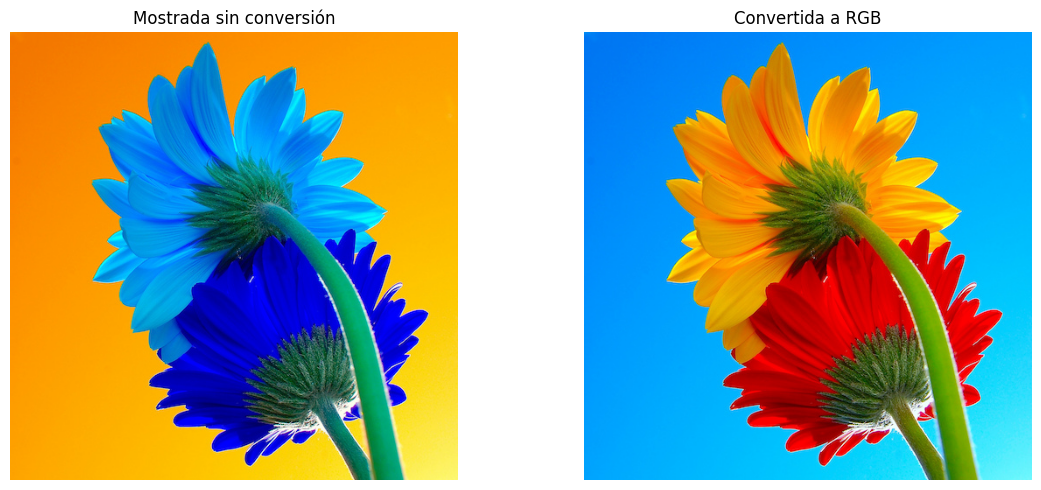

Forma: (512, 512, 3)
Tipo de dato: uint8


In [3]:
imagen_bgr = cv2.imread(str(ruta))
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(imagen_bgr)
axes[0].set_title("Mostrada sin conversión")
axes[0].axis("off")

axes[1].imshow(imagen_rgb)
axes[1].set_title("Convertida a RGB")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Forma: {imagen_rgb.shape}")
print(f"Tipo de dato: {imagen_rgb.dtype}")


## 1. Separar canales

Antes de elegir umbrales, conviene mirar qué ocurre en cada canal. En una segmentación por color, esa observación previa evita que el valor de corte quede elegido al azar.


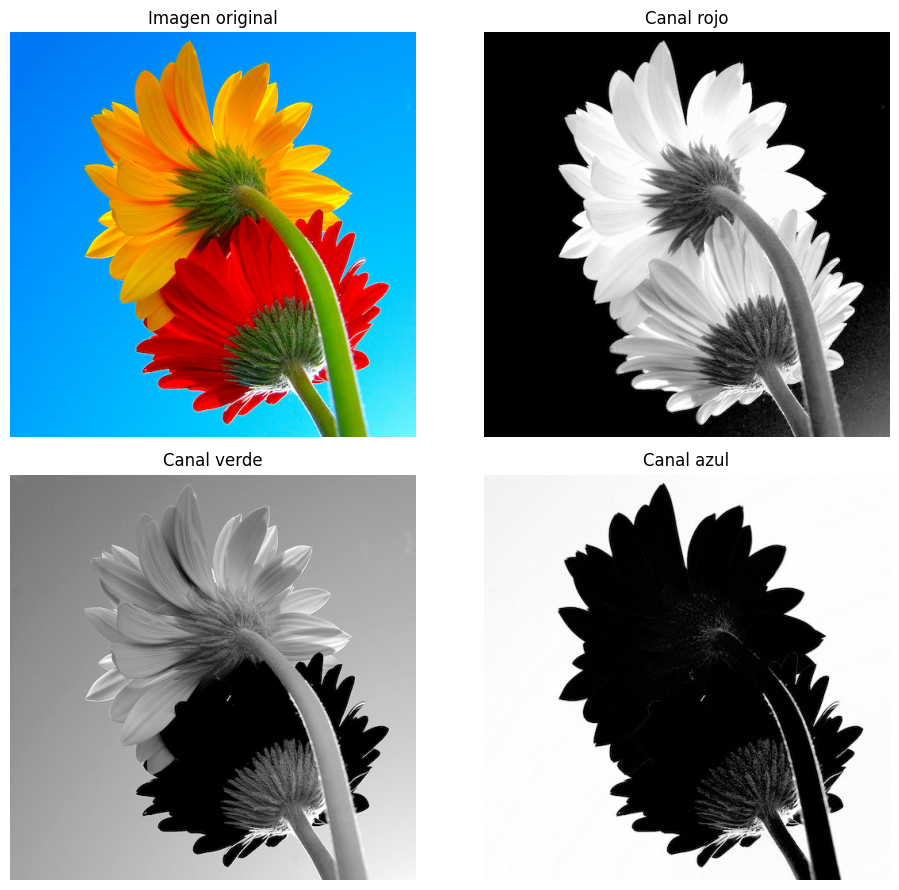

In [4]:
canal_rojo = imagen_rgb[:, :, 0]
canal_verde = imagen_rgb[:, :, 1]
canal_azul = imagen_rgb[:, :, 2]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes[0, 0].imshow(imagen_rgb)
axes[0, 0].set_title("Imagen original")
axes[0, 0].axis("off")

axes[0, 1].imshow(canal_rojo, cmap="gray")
axes[0, 1].set_title("Canal rojo")
axes[0, 1].axis("off")

axes[1, 0].imshow(canal_verde, cmap="gray")
axes[1, 0].set_title("Canal verde")
axes[1, 0].axis("off")

axes[1, 1].imshow(canal_azul, cmap="gray")
axes[1, 1].set_title("Canal azul")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


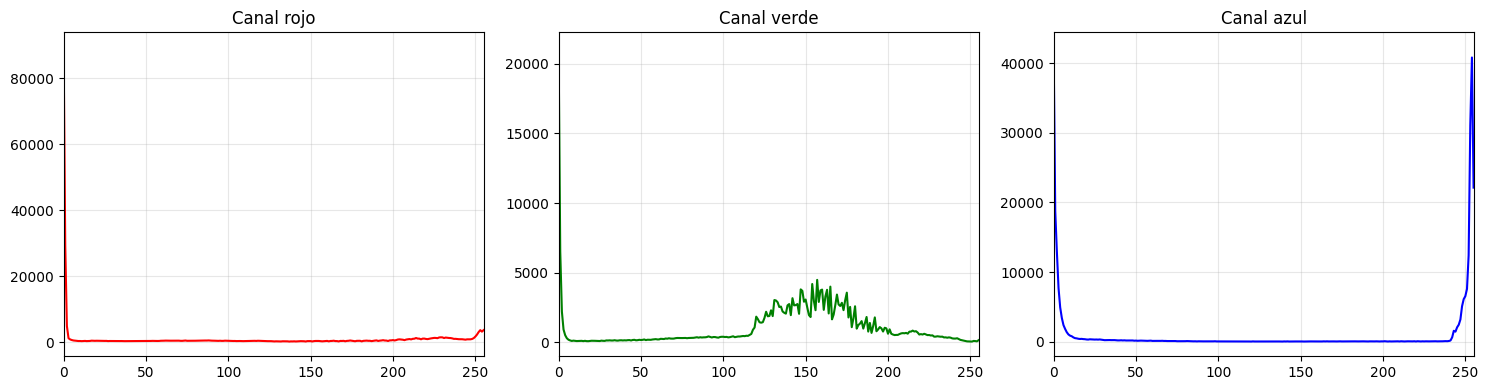

In [5]:
mostrar_histogramas(canal_rojo, canal_verde, canal_azul)


## 2. Primera segmentación

Vamos a empezar con una estrategia simple para flores rojas:

- mucho rojo,
- poco verde,
- poco azul.

Estos valores no son "la respuesta correcta". Son un punto de partida para discutir si la máscara resulta demasiado estricta, demasiado relajada o razonable.


Píxeles segmentados: 31261
Porcentaje de la imagen: 11.93%


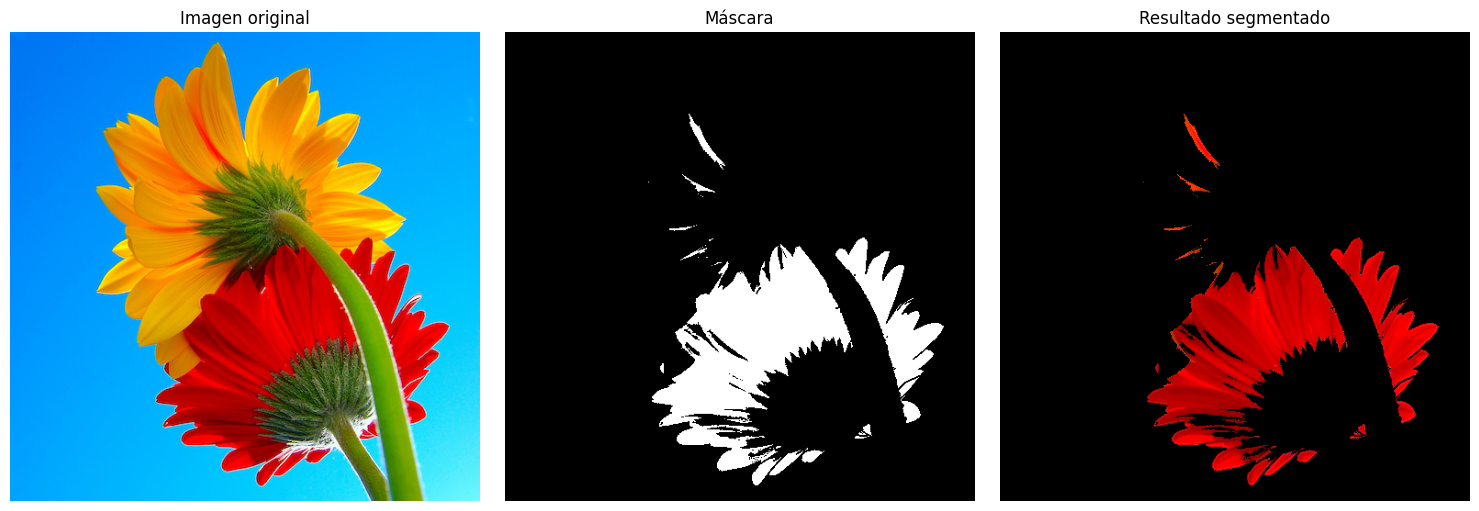

In [6]:
umbral_rojo = 150
umbral_verde = 70
umbral_azul = 70
etiqueta_segmentada = "flores rojas"

mascara = segmentar_color(imagen_rgb, umbral_rojo, umbral_verde, umbral_azul)
imagen_segmentada = imagen_rgb.copy()
imagen_segmentada[~mascara] = 0

print(f"Píxeles segmentados: {np.sum(mascara)}")
print(f"Porcentaje de la imagen: {100 * np.sum(mascara) / mascara.size:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(mascara, cmap="gray")
axes[1].set_title("Máscara")
axes[1].axis("off")

axes[2].imshow(imagen_segmentada)
axes[2].set_title("Resultado segmentado")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 3. Delimitar y rotular lo segmentado

Segmentar no solo sirve para separar una región del resto de la imagen. También permite localizarla. En esta parte vamos a dibujar una caja delimitadora sobre la región segmentada y a escribir qué objeto o zona fue seleccionada.


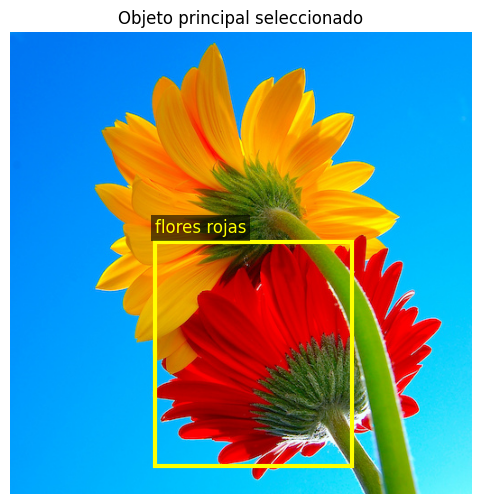

Se segmentó: flores rojas
Área del objeto principal: 22700 píxeles
Caja delimitadora -> x = 160, y = 232, ancho = 219, alto = 248


In [7]:
dibujar_caja_delimitadora(imagen_rgb, mascara, etiqueta_segmentada)


## 4. Comparar estrategias

Una decisión importante en segmentación es revisar qué cambia cuando modificás los umbrales. Acá se comparan tres configuraciones: una más estricta, una intermedia y otra más relajada.


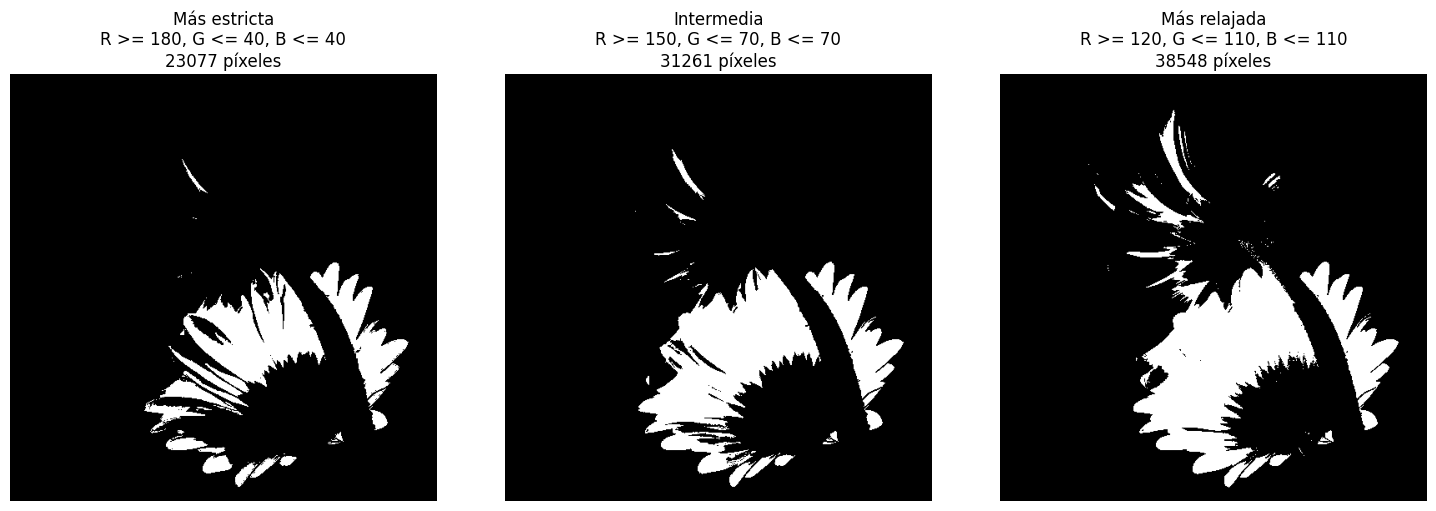

In [8]:
configuraciones = [
    (180, 40, 40, "Más estricta"),
    (150, 70, 70, "Intermedia"),
    (120, 110, 110, "Más relajada"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (r_min, g_max, b_max, titulo) in zip(axes, configuraciones):
    mascara_temp = segmentar_color(imagen_rgb, r_min, g_max, b_max)
    ax.imshow(mascara_temp, cmap="gray")
    ax.set_title(
        f"{titulo}\nR >= {r_min}, G <= {g_max}, B <= {b_max}\n{np.sum(mascara_temp)} píxeles"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Cuantización y segmentación

Ya trabajaste cuantización en el cuaderno anterior. Ahora podés ver cómo una reducción de niveles también modifica el comportamiento de la segmentación.


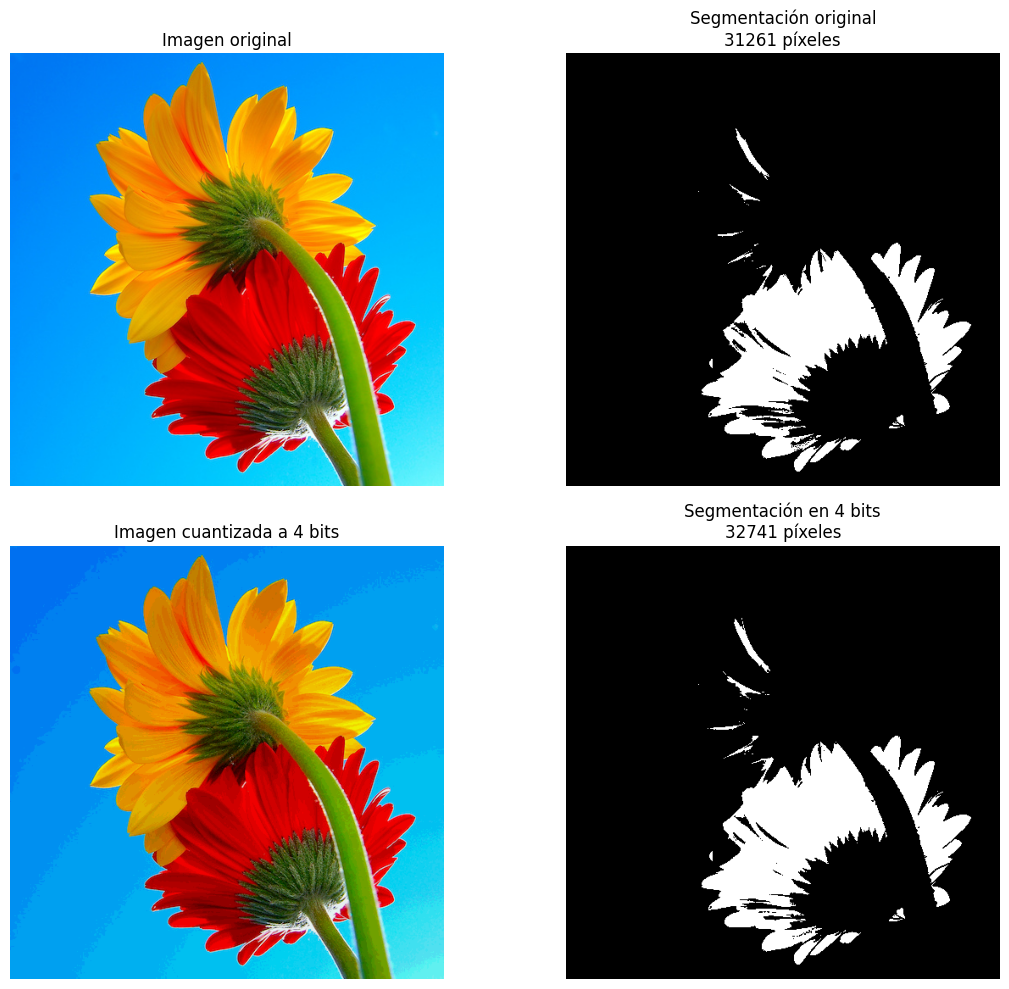

In [9]:
imagen_4bits = (imagen_rgb // 16) * 16
mascara_8bits = segmentar_color(imagen_rgb, 150, 70, 70)
mascara_4bits = segmentar_color(imagen_4bits, 144, 64, 64)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(imagen_rgb)
axes[0, 0].set_title("Imagen original")
axes[0, 0].axis("off")

axes[0, 1].imshow(mascara_8bits, cmap="gray")
axes[0, 1].set_title(f"Segmentación original\n{np.sum(mascara_8bits)} píxeles")
axes[0, 1].axis("off")

axes[1, 0].imshow(imagen_4bits)
axes[1, 0].set_title("Imagen cuantizada a 4 bits")
axes[1, 0].axis("off")

axes[1, 1].imshow(mascara_4bits, cmap="gray")
axes[1, 1].set_title(f"Segmentación en 4 bits\n{np.sum(mascara_4bits)} píxeles")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Cierre del laboratorio

Antes de pasar a la actividad integradora, vale la pena revisar estas preguntas:

- ¿qué canal te dio más información útil para elegir umbrales?
- ¿qué problema apareció cuando los umbrales fueron demasiado relajados?
- ¿qué información nueva aportó la caja delimitadora?
- ¿cómo afectó la cuantización a la máscara final?

La actividad integradora retoma estas ideas, pero ahora te va a pedir más decisión, más justificación propia y una defensa clara de la estrategia que elijas.
